This is a Notebook for Gaussian Process based supervised learning

Best params: {'GP_reg__kernel__k1__k2__length_scale': 0.5, 'GP_reg__kernel__k2__noise_level': 0.01}
Best CV score: -0.09242963208471833


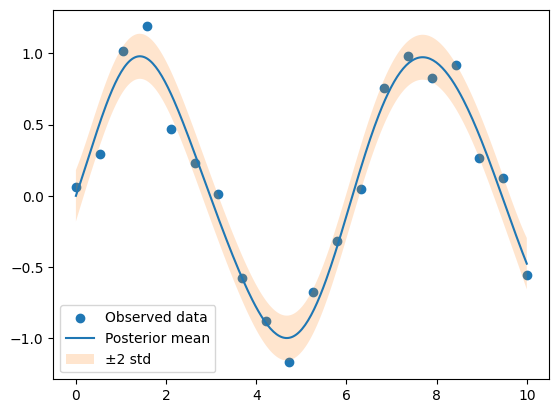

1**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.01)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Training data
rng = np.random.default_rng(42)

X = np.linspace(0, 10, 20).reshape(-1, 1)
y = np.sin(X[:, 0]) + 0.2 * rng.normal(size=len(X))

# Base kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("GP_reg", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=42,
        optimizer=None   # tune hyperparameters
    ))
])

parameter_grid = {
    "GP_reg__kernel__k1__k2__length_scale": [0.01, 0.1, 0.5, 1, 10, 100],
    "GP_reg__kernel__k2__noise_level": [0.01, 0.1, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    cv=cv,
    scoring="neg_mean_squared_error"
)

search.fit(X, y)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

best_model = search.best_estimator_

# Test inputs
X_test = np.linspace(0, 10, 300).reshape(-1, 1)

mean, std = best_model.predict(X_test, return_std=True)

plt.scatter(X[:, 0], y, label="Observed data")
plt.plot(X_test[:, 0], mean, label="Posterior mean")
plt.fill_between(
    X_test[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.2,
    label="±2 std"
)

plt.legend()
plt.show()

print(best_model.named_steps["GP_reg"].kernel_)